# Telugu NER Dataset Analysis (Naamapadam)

In this notebook, we will analyze the Telugu portion of the **Naamapadam dataset**.  
The dataset is for **Named Entity Recognition (NER)**, which means the task is to identify and classify named entities like person names, locations, organizations, etc.  

In this step, we loaded the Naamapadam Telugu dataset using HuggingFace datasets library.
It contains three splits: Train, Validation, and Test.
These splits will be used for model training, hyperparameter tuning, and evaluation.

# Telugu NER: Advanced EDA (Naamapadam)
This notebook performs advanced exploratory data analysis (EDA) on the Naamapadam Telugu dataset.
It follows 15 steps: load, inspect, save CSVs, tag/sentence stats, BIO checks, ambiguity, rare-entities,
unicode audit, split comparisons and an auto-generated insights summary.


In [ ]:
# Step 0: Install & imports
!pip install -q datasets==2.14.5 seaborn wordcloud scipy

from datasets import load_dataset
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from collections import Counter, defaultdict
from tqdm.auto import tqdm
import json, unicodedata, itertools
from scipy.stats import wasserstein_distance, entropy, ttest_ind
from math import sqrt
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,5)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.6/519.6 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 7.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2023.6.0 which is incompatible.


###  Load Telugu dataset
We load the HuggingFace `ai4bharat/naamapadam` dataset with the "te" config (Telugu).


In [ ]:
lang = "te"   # Telugu
ds = load_dataset("ai4bharat/naamapadam", lang)
ds


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 507741
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 847
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 2700
    })
})

###  Peek & schema
Inspect dataset structure and print a sample example to confirm fields `tokens` and `ner_tags`.


In [ ]:
print("Splits:", ds)
print("\nTrain features:\n", ds["train"].features)
print("\nExample 0 (train):")
print(ds["train"][0])


Splits: DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 507741
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 847
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 2700
    })
})

Train features:
 {'tokens': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None), 'ner_tags': Sequence(feature=ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC'], id=None), length=-1, id=None)}

Example 0 (train):
{'tokens': ['స్థాపించబడిన', 'సాఫ్ట్వేర్'], 'ner_tags': [3, 0]}


###  Save CSVs to Drive (train / validation / test)
Save each split to CSV for offline inspection (tokens/ner_tags saved as JSON strings).


In [ ]:
import os
os.makedirs("naamapadam_te_csv", exist_ok=True)

def split_to_df(split):
    rows = []
    id2label = ds["train"].features["ner_tags"].feature.names
    for ex in split:
        rows.append({
            "tokens": json.dumps(ex["tokens"], ensure_ascii=False),
            "ner_tags": json.dumps([id2label[t] for t in ex["ner_tags"]], ensure_ascii=False)
        })
    return pd.DataFrame(rows)

df_train = split_to_df(ds["train"])
df_val   = split_to_df(ds["validation"])
df_test  = split_to_df(ds["test"])

df_train.to_csv("naamapadam_te_csv/telugu_train.csv", index=False)
df_val.to_csv("naamapadam_te_csv/telugu_val.csv", index=False)
df_test.to_csv("naamapadam_te_csv/telugu_test.csv", index=False)

print("Saved CSVs to folder: naamapadam_te_csv")
print("Download from Colab files panel or use files.download if needed.")


Saved CSVs to folder: naamapadam_te_csv
Download from Colab files panel or use files.download if needed.


###  Basic dataset stats
Compute number of sentences, number of tokens and average sentence length per split.


In [ ]:
def count_sentences(split): return len(ds[split])
def count_tokens(split):    return sum(len(x) for x in ds[split]["tokens"])

sizes = {s: count_sentences(s) for s in ds.keys()}
tokens = {s: count_tokens(s) for s in ds.keys()}
avg_len = {s: tokens[s]/sizes[s] for s in ds.keys()}

print("Sentence counts:", sizes)
print("Token counts:", tokens)
print("Average sentence length (tokens):", {k: round(v,2) for k,v in avg_len.items()})


Sentence counts: {'train': 507741, 'test': 847, 'validation': 2700}
Token counts: {'train': 5140539, 'test': 8678, 'validation': 27745}
Average sentence length (tokens): {'train': 10.12, 'test': 10.25, 'validation': 10.28}


### NER-tag distribution (token-level)
Count token-level NER labels (O, B-PER, I-PER, etc.) in the training split and plot a bar chart.


,tag_id,count,tag
2,5,205915,B-LOC
0,3,194062,B-ORG
3,1,347841,B-PER
5,6,43160,I-LOC
6,4,184519,I-ORG
4,2,288420,I-PER
1,0,3876622,O


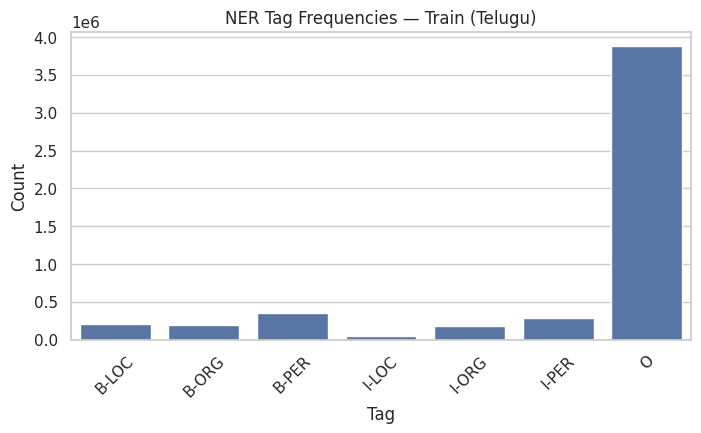

Proportions (token-level): {'B-ORG': 0.0378, 'O': 0.7541, 'B-LOC': 0.0401, 'B-PER': 0.0677, 'I-PER': 0.0561, 'I-LOC': 0.0084, 'I-ORG': 0.0359}


In [ ]:
id2label = ds["train"].features["ner_tags"].feature.names
all_tags = [t for sent in ds["train"]["ner_tags"] for t in sent]
tag_counts = Counter(all_tags)
tag_df = pd.DataFrame({
    "tag_id": list(tag_counts.keys()),
    "count":  list(tag_counts.values())
})
tag_df["tag"] = tag_df["tag_id"].map(lambda i: id2label[i])
tag_df = tag_df.sort_values("tag")
display(tag_df)

plt.figure(figsize=(8,4))
sns.barplot(data=tag_df, x="tag", y="count")
plt.title("NER Tag Frequencies — Train (Telugu)")
plt.xlabel("Tag"); plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

total_tokens = sum(tag_counts.values())
prop_map = {id2label[k]: round(v/total_tokens,4) for k,v in tag_counts.items()}
print("Proportions (token-level):", prop_map)


,0
count,507741.000000
mean,10.124333
std,7.982519
min,1.000000
25%,5.000000
50%,8.000000
75%,13.000000
max,100.000000


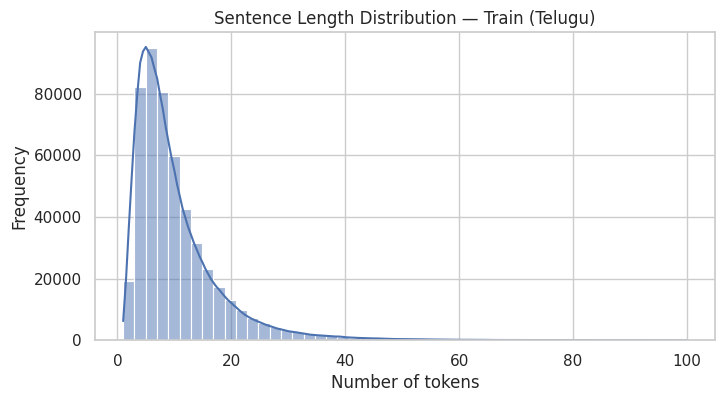

In [ ]:
train_lens = [len(toks) for toks in ds["train"]["tokens"]]
s = pd.Series(train_lens)
display(s.describe())

plt.figure(figsize=(8,4))
sns.histplot(train_lens, bins=50, kde=True)
plt.title("Sentence Length Distribution — Train (Telugu)")
plt.xlabel("Number of tokens"); plt.ylabel("Frequency")
plt.show()


###  Extract entities (BIO spans)
Convert BIO tags to entity spans (surface, type, token-length). We'll use these spans for several analyses.


In [ ]:
def extract_entities(tokens, tags, id2label):
    ents, cur, typ = [], [], None
    for tok, tag_id in zip(tokens, tags):
        tag = id2label[tag_id]
        if tag.startswith("B-"):
            if cur:
                ents.append((" ".join(cur), typ, len(cur)))
            cur, typ = [tok], tag[2:]
        elif tag.startswith("I-") and cur and typ == tag[2:]:
            cur.append(tok)
        else:
            if cur:
                ents.append((" ".join(cur), typ, len(cur)))
                cur, typ = [], None
    if cur:
        ents.append((" ".join(cur), typ, len(cur)))
    return ents

all_entities = []
for row in tqdm(ds["train"], desc="Extracting entities"):
    all_entities.extend(extract_entities(row["tokens"], row["ner_tags"], id2label))

print("Extracted entities (sample 10):", all_entities[:10])
ent_type_counts = Counter([t for _,t,_ in all_entities])
print("Entity counts by type:", ent_type_counts)


Extracting entities:   0%|          | 0/507741 [00:00<?, ?it/s]

Extracted entities (sample 10): [('స్థాపించబడిన', 'ORG', 1), ('ఇండోనేషియాలో', 'LOC', 1), ('డేవిడ్ వార్నర్', 'PER', 2), ('గుజరాత్ రాష్ట్రంలో', 'LOC', 2), ('డయులో', 'LOC', 1), ('గుజరాత్ పీసీసీ', 'ORG', 2), ('భరత్ సింగ్ సోలంకి', 'PER', 3), ('సిద్ధార్థ్ పటేల్', 'PER', 2), ('బాబూభాయి మంగుకియా', 'PER', 2), ('చిరంజీవి , మోహన్ బాబు', 'PER', 4)]
Entity counts by type: Counter({'PER': 347841, 'LOC': 205915, 'ORG': 194062})


### BIO validity & annotation issues
Check for invalid BIO sequences (I- without preceding B-) and build token→label sets to find ambiguous tokens.


In [ ]:
def is_bio_valid(tags, id2label):
    prev = "O"
    for tid in tags:
        tag = id2label[tid]
        if tag.startswith("I-"):
            if not (prev.startswith("B-") or prev.startswith("I-")) or prev[2:] != tag[2:]:
                return False
        prev = tag
    return True

invalid_bio = sum(not is_bio_valid(r["ner_tags"], id2label) for r in ds["train"])
print("Invalid BIO sequences (train):", invalid_bio)

# Ambiguity: token -> set(labels)
token_labels = defaultdict(set)
for toks, tags in zip(ds["train"]["tokens"], ds["train"]["ner_tags"]):
    for t, tid in zip(toks, tags):
        token_labels[t].add(id2label[tid])

ambiguous = {t: labs for t, labs in token_labels.items() if len(labs) > 1}
print("Ambiguous tokens (count):", len(ambiguous))
print("Examples (token -> labels):", list(itertools.islice(ambiguous.items(), 10)))


Invalid BIO sequences (train): 1367
Ambiguous tokens (count): 50637
Examples (token -> labels): [('స్థాపించబడిన', {'O', 'B-ORG'}), ('సాఫ్ట్వేర్', {'I-ORG', 'B-LOC', 'B-ORG', 'I-PER', 'O'}), ('ఈ', {'I-ORG', 'B-LOC', 'B-PER', 'B-ORG', 'I-LOC', 'I-PER', 'O'}), ('స్మార్ట్', {'I-ORG', 'B-LOC', 'B-PER', 'B-ORG', 'I-LOC', 'I-PER', 'O'}), ('ఫోన్', {'I-ORG', 'B-PER', 'B-ORG', 'I-PER', 'O'}), ('ఇప్పటికే', {'I-ORG', 'B-PER', 'O'}), ('ఇండోనేషియాలో', {'B-LOC', 'O'}), ('లాంచ్', {'I-ORG', 'B-ORG', 'I-LOC', 'O'}), ('అయింది', {'I-ORG', 'O'}), ('.', {'I-ORG', 'B-LOC', 'B-PER', 'B-ORG', 'I-LOC', 'I-PER', 'O'})]


### Step 9: Rare entity surface forms
Find entity surface forms that appear fewer than 5 times (these are "rare" and likely cause learning difficulty).


In [ ]:
surface_counts = Counter([e for e,_,__ in all_entities])
rare = [e for e,c in surface_counts.items() if c < 5]
print("Total rare surfaces (appear <5):", len(rare))
print("Sample rare entities:", rare[:20])


Total rare surfaces (appear <5): 197035
Sample rare entities: ['స్థాపించబడిన', 'గుజరాత్ రాష్ట్రంలో', 'డయులో', 'గుజరాత్ పీసీసీ', 'భరత్ సింగ్ సోలంకి', 'సిద్ధార్థ్ పటేల్', 'బాబూభాయి మంగుకియా', 'చిరంజీవి , మోహన్ బాబు', 'టి సుబ్బిరామిరెడ్డి', 'పిప్రితాన్', 'నూజివీడు రోడ్డు', 'Gcalctool', 'హ్యుందాయ్ ఎలాంట్రా', 'ద్రవిడ కళగం', 'ద్రవిడ మున్నేట్ర కళగం', 'బాఘి', 'తెలంగాణ కాంగ్రెస్ నేతలు అమరులయ్యారంటున్న', 'రఘువంశ్ ప్రసాద్ సింగ్', 'ఉత్తర్ప్రదేశ్కి', 'ఫోర్డ్ వాహనాలపై']


###  Character/Token length per entity type
Compute descriptive stats for entity span lengths (in tokens) and character lengths per entity type.


In [ ]:
df_ent = pd.DataFrame(all_entities, columns=["surface","etype","span_tokens"])
df_ent["chars"] = df_ent["surface"].apply(len)

print("Token-length by type:")
display(df_ent.groupby("etype")["span_tokens"].describe())

print("\nChar-length by type:")
display(df_ent.groupby("etype")["chars"].describe())


Token-length by type:


,count,mean,std,min,25%,50%,75%,max
etype,,,,,,,,
LOC,205915.0,1.208120,0.723285,1.0,1.0,1.0,1.0,52.0
ORG,194062.0,1.934392,1.704732,1.0,1.0,1.0,2.0,79.0
PER,347841.0,1.823051,1.001015,1.0,1.0,2.0,2.0,40.0



Char-length by type:


,count,mean,std,min,25%,50%,75%,max
etype,,,,,,,,
LOC,205915.0,9.247947,5.514832,1.0,6.0,8.0,11.0,328.0
ORG,194062.0,13.990235,12.388141,1.0,6.0,10.0,18.0,546.0
PER,347841.0,11.847853,6.778844,1.0,8.0,11.0,14.0,270.0


###  Train vs Test distribution comparisons
Compare entity-density and sentence-length distributions between train and test:
- compute p-value (ttest), KL divergence, Wasserstein distance and Cohen's d.


In [ ]:
def sentence_lengths(split): return [len(x) for x in ds[split]["tokens"]]
def entity_density(split):
    dens = []
    for toks, tags in zip(ds[split]["tokens"], ds[split]["ner_tags"]):
        ent_tokens = sum(1 for t in tags if id2label[t] != "O")
        dens.append(ent_tokens / max(1, len(toks)))
    return dens

tr_len, te_len = sentence_lengths("train"), sentence_lengths("test")
tr_den, te_den = entity_density("train"), entity_density("test")

def kl_divergence(p, q, bins=50):
    hist_p, bin_edges = np.histogram(p, bins=bins, density=True)
    hist_q, _ = np.histogram(q, bins=bin_edges, density=True)
    eps = 1e-12
    P = hist_p + eps; Q = hist_q + eps
    P /= P.sum(); Q /= Q.sum()
    return float(entropy(P, Q))

def cohens_d(a, b):
    a, b = np.array(a), np.array(b)
    m1, m2 = a.mean(), b.mean()
    s1, s2 = a.std(ddof=1), b.std(ddof=1)
    n1, n2 = len(a), len(b)
    sp = sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
    return float((m2 - m1) / (sp + 1e-12))

from scipy.stats import ttest_ind

# Compare entity density
pval_den = ttest_ind(tr_den, te_den, equal_var=False).pvalue
kl_den = kl_divergence(tr_den, te_den, bins=50)
w_den = wasserstein_distance(tr_den, te_den)
d_den = cohens_d(tr_den, te_den)

# Compare sentence length
pval_len = ttest_ind(tr_len, te_len, equal_var=False).pvalue
kl_len = kl_divergence(tr_len, te_len, bins=50)
w_len = wasserstein_distance(tr_len, te_len)
d_len = cohens_d(tr_len, te_len)

summary_comp = {
    "entity_density": {"p_value": round(pval_den,6), "KL": round(kl_den,4), "Wasserstein": round(w_den,4), "Cohen_d": round(d_den,4)},
    "sentence_length": {"p_value": round(pval_len,6), "KL": round(kl_len,4), "Wasserstein": round(w_len,4), "Cohen_d": round(d_len,4)}
}
summary_comp


{'entity_density': {'p_value': np.float64(0.225017),
  'KL': 0.1843,
  'Wasserstein': np.float64(0.0113),
  'Cohen_d': -0.0397},
 'sentence_length': {'p_value': np.float64(0.654285),
  'KL': 0.1078,
  'Wasserstein': np.float64(0.3214),
  'Cohen_d': 0.0152}}

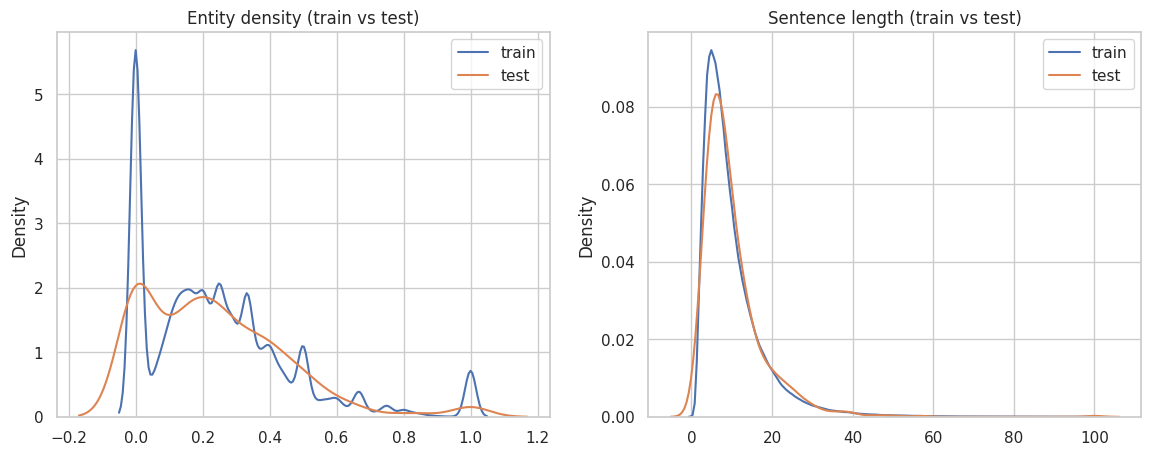

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(14,5))
sns.kdeplot(tr_den, ax=ax[0], label="train", bw_adjust=1)
sns.kdeplot(te_den, ax=ax[0], label="test", bw_adjust=1)
ax[0].set_title("Entity density (train vs test)"); ax[0].legend()

sns.kdeplot(tr_len, ax=ax[1], label="train", bw_adjust=1)
sns.kdeplot(te_len, ax=ax[1], label="test", bw_adjust=1)
ax[1].set_title("Sentence length (train vs test)"); ax[1].legend()
plt.show()


###  Unicode normalization audit (NFC)
Check how many tokens change under Unicode NFC normalization (common source of duplicates/noise).


In [ ]:
changed = 0
examples = []
total = 0
for toks in ds["train"]["tokens"]:
    for t in toks:
        total += 1
        n = unicodedata.normalize("NFC", t)
        if n != t:
            changed += 1
            if len(examples) < 20:
                examples.append((t, n))
print(f"Tokens changed by NFC normalization: {changed}/{total} ({100*changed/total:.4f}%)")
examples[:20]


Tokens changed by NFC normalization: 1/5140539 (0.0000%)


[('fɑ̀lǔ', 'fɑ̀lǔ')]

###  Long-span outliers (>8 tokens)
List multi-token entities longer than 8 tokens for manual review (likely annotation/guideline issues).


In [ ]:
long_spans = [e for e in all_entities if e[2] > 8]
print("Count of long spans (>8 tokens):", len(long_spans))
long_spans[:20]


Count of long spans (>8 tokens): 2661


[('చర్చ్ ఆఫ్ క్రైస్ట్ ఛారిటబుల్ ట్రస్ట్ అండ్ ఎడ్యుకేషనల్ ఛారిటబుల్ సొసైటీ',
  'ORG',
  9),
 ('18 స్టూడియోస్ పతాకాలపై నాగార్జున అక్కినేని , పి . కిరణ్ ( జెమిని కిరణ్',
  'ORG',
  12),
 ('శాస్త్ర విజ్ఞాన - సాంకేతిక విజ్ఞాన మంత్రిత్వ శాఖ కోవిడ్ - 19 కు సంబంధించి పిసిఆర్ , ల్యాంప్ పరీక్షల కోసం మాగ్నెటిక్ నానోపార్టికల్ ఆధారిత ఆర్ ఎన్ ఎ వెలికితీత కిట్ను అభివృద్ధి చేసిన శ్రీ చిత్ర తిరునాల్ ఇన్స్టిట్యూట్',
  'ORG',
  31),
 ('శ్రీ చిత్ర తిరునాల్ ఇన్స్టిట్యూట్ ఫర్ మెడికల్ సైన్సెస్ అండ్ టెక్నాలజీ',
  'ORG',
  9),
 ("గిరిజన ఉత్పత్తుల అభివృద్ధి , మార్కెటింగ్కు శాఖా పరంగా సహాయం ' పథకం కింద మైనర్ అటవీ ఉత్పత్తి వస్తువుల కనీస",
  'ORG',
  16),
 ('శాస్త్ర విజ్ఞాన - సాంకేతిక విజ్ఞాన మంత్రిత్వ శాఖ కోవిడ్ - 19 వైరస్ గుర్తింపునకు సిఎస్ ఐఆర్',
  'ORG',
  14),
 ('24 ఫ్రేమ్స్ ఫ్యాక్టరీ బ్యానర్పై మంచు విష్ణు నిర్మిస్తుండగా , ఏవీఏ ఎంటర్టైన్మెంట్ నిర్మాణ సంస్థ',
  'ORG',
  12),
 ('బ్యాంక్ ఆఫ్ ఇండియా తన నెంబర్స్ను విడుదల చేస్తుండడంతో 1శాతం వరకు స్టేట్ బ్యాంక్ ఆఫ్ ఇండియా',
  'ORG',
  13),
 ('కమిషన్ తన 158వ నివేదికల

### Split leakage / conflicting labels across splits
Detect surfaces that appear with different entity types across train/validation/test (potential label inconsistency).


In [ ]:
def surface_labels(split):
    store = defaultdict(set)
    for row in ds[split]:
        ents = extract_entities(row["tokens"], row["ner_tags"], id2label)
        for surface, etype, _ in ents:
            store[surface].add(etype)
    return store

train_sur = surface_labels("train")
test_sur  = surface_labels("test")
val_sur   = surface_labels("validation")

def conflicts(store):
    return {s: labs for s, labs in store.items() if len(labs) > 1}

conf_train = conflicts(train_sur)
conf_test  = conflicts(test_sur)
conf_val   = conflicts(val_sur)

cross_conf = {}
for s in set(train_sur.keys()).intersection(test_sur.keys()):
    if len(train_sur[s].union(test_sur[s])) > 1:
        cross_conf[s] = (train_sur[s], test_sur[s])

print("Conflicts within train:", len(conf_train))
print("Conflicts within test:", len(conf_test))
print("Conflicts within val:", len(conf_val))
print("Cross-split conflicts (train vs test):", len(cross_conf))
list(itertools.islice(cross_conf.items(), 10))


Conflicts within train: 7332
Conflicts within test: 6
Conflicts within val: 27
Cross-split conflicts (train vs test): 282


[('రోహిణి', ({'LOC', 'ORG', 'PER'}, {'PER'})),
 ('కొత్తపేట', ({'LOC', 'ORG'}, {'LOC'})),
 ('రాఫెల్', ({'ORG', 'PER'}, {'PER'})),
 ('మంగుళూరు', ({'LOC', 'ORG'}, {'LOC'})),
 ('మోడీ', ({'LOC', 'ORG', 'PER'}, {'PER'})),
 ('అద్వానీ', ({'LOC', 'ORG', 'PER'}, {'PER'})),
 ('మదీనా', ({'LOC', 'PER'}, {'LOC'})),
 ('ఇండియా', ({'LOC', 'ORG', 'PER'}, {'LOC'})),
 ('రజనీ', ({'LOC', 'PER'}, {'PER'})),
 ('రాహుల్ గాంధీ', ({'ORG', 'PER'}, {'PER'}))]

###  Auto-generate Insights text
This cell composes a short human-readable summary of main numbers and findings for quick reporting.


In [ ]:
# Prepare numbers
n_train, n_val, n_test = sizes["train"], sizes["validation"], sizes["test"]
avg_train_len = round(np.mean(train_lens), 2)
# Most frequent token-level tag
top_tag_id, top_tag_count = tag_df.sort_values("count", ascending=False).iloc[0][["tag_id","count"]]
top_tag_name = id2label[int(top_tag_id)]

o_prop = None
if "O" in tag_df["tag"].values:
    o_prop = float(tag_df.loc[tag_df["tag"]=="O","count"].values[0]) / total_tokens

summary_lines = []
summary_lines.append(f"**Dataset size** — train: {n_train}, validation: {n_val}, test: {n_test}.")
summary_lines.append(f"**Entity labels present** — {', '.join(sorted({lab.split('-')[-1] if '-' in lab else lab for lab in id2label}))}.")
summary_lines.append(f"**Most frequent tag (token-level)** — {top_tag_name} ({top_tag_count} occurrences).")
if o_prop is not None:
    summary_lines.append(f"**Non-entity 'O' proportion** — {round(o_prop*100,2)}% of tokens.")
summary_lines.append(f"**Average sentence length (train)** — ~{avg_train_len} tokens.")
summary_lines.append(f"**Invalid BIO sequences** — {invalid_bio} (train).")
summary_lines.append(f"**Ambiguous tokens** — {len(ambiguous)} tokens appear with multiple labels.")
summary_lines.append(f"**Rare entities (surface <5)** — {len(rare)} unique surfaces.")
summary_lines.append("**Entity type counts (surface-level)** — " + ", ".join([f"{k}:{v}" for k,v in ent_type_counts.items()]))
summary_lines.append("**Train vs Test (entity density)** — p={p}, KL={kl}, W={w}, d={d}".format(
    p=summary_comp['entity_density']['p_value'], kl=summary_comp['entity_density']['KL'],
    w=summary_comp['entity_density']['Wasserstein'], d=summary_comp['entity_density']['Cohen_d']))
summary_lines.append("**Train vs Test (sentence length)** — p={p}, KL={kl}, W={w}, d={d}".format(
    p=summary_comp['sentence_length']['p_value'], kl=summary_comp['sentence_length']['KL'],
    w=summary_comp['sentence_length']['Wasserstein'], d=summary_comp['sentence_length']['Cohen_d']))

insights_text = "\n".join(["- " + s for s in summary_lines])
print(insights_text)


- **Dataset size** — train: 507741, validation: 2700, test: 847.
- **Entity labels present** — LOC, O, ORG, PER.
- **Most frequent tag (token-level)** — O (3876622 occurrences).
- **Non-entity 'O' proportion** — 75.41% of tokens.
- **Average sentence length (train)** — ~10.12 tokens.
- **Invalid BIO sequences** — 1367 (train).
- **Ambiguous tokens** — 50637 tokens appear with multiple labels.
- **Rare entities (surface <5)** — 197035 unique surfaces.
- **Entity type counts (surface-level)** — ORG:194062, LOC:205915, PER:347841
- **Train vs Test (entity density)** — p=0.225017, KL=0.1843, W=0.0113, d=-0.0397
- **Train vs Test (sentence length)** — p=0.654285, KL=0.1078, W=0.3214, d=0.0152
